<a href="https://colab.research.google.com/github/syhennie/data-quality-process/blob/main/features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Настройка окружения

In [ ]:
%pip install numpy gensim pandas scipy sdv matplotlib graphviz faker

Note: you may need to restart the kernel to use updated packages.


In [53]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sdv
import pathlib

In [ ]:
df = pd.read_csv(pathlib.Path('../test.csv'))
df = df.iloc[:, 1:]
df.head()

,article,highlights
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."


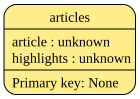

In [ ]:
import faker
from faker.providers import lorem
from sdv.metadata import Metadata

fake = faker.Faker("en_US", ["faker.providers.lorem"])

metadata = Metadata.detect_from_dataframes(
    data={
        'articles': df
    },
    infer_sdtypes=False)

metadata.visualize()
metadata.update_columns(
    column_names=['article', 'highlights'],
    sdtype='sentence',
    table_name='articles'
)

metadata.visualize()
# metadata.validate()

In [96]:
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer

synthesizer = CTGANSynthesizer(metadata)
# synthesizer = TVAESynthesizer(metadata)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data

,article,highlights
0,sdv-pii-colb0,sdv-pii-fe1jx
1,sdv-pii-9xkkg,sdv-pii-hpibj
2,sdv-pii-c3tr1,sdv-pii-68uuv
3,sdv-pii-w6kdc,sdv-pii-0qi6e
4,sdv-pii-bmz0x,sdv-pii-ut1r9
...,...,...
995,sdv-pii-d9azg,sdv-pii-czgrg
996,sdv-pii-q86id,sdv-pii-qh55s
997,sdv-pii-orznm,sdv-pii-vt2gw
998,sdv-pii-k83jw,sdv-pii-ysynm


In [77]:
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess

model = FastText.load("../fasttext_lee_background")

def get_vectorised_entries(entries):
    features = []
    for entry in entries:
        tokens = simple_preprocess(entry, min_len=1)
        vectors = [model.wv[token] for token in tokens]
        features.append(np.mean(vectors, axis=0))
    return np.array(features)

In [97]:
summary_stats = []
features_data = []

df_sample = df.sample(1000)

for column in df_sample.columns:
    entries = [x for x in df_sample[column]]
    features = get_vectorised_entries(entries)

    # Features-based metrics
    
    mean = np.mean(features, axis=0)
    standard_deviation = np.std(features, axis=0)
    median = np.median(features, axis=0)
    asymmetry = stats.skew(features, axis=0)
    excess = stats.kurtosis(features, axis=0)
    
    summary_stats.append({
        'column': column,
        'overall_mean': np.mean(mean),
        'overall_std': np.mean(standard_deviation),
        'std_of_means': np.std(mean),
        'mean_of_medians': np.mean(median),
        'asymmetry_avg': np.mean(asymmetry),
        'excess_avg': np.mean(excess),
        'n_entries': len(entries),
        'vector_dim': features.shape[1]
    })

    features_data.append({
            'column': column,
            'vectors': features
        })

summary_df = pd.DataFrame(summary_stats)
summary_df

,column,overall_mean,overall_std,std_of_means,mean_of_medians,asymmetry_avg,excess_avg,n_entries,vector_dim
0,article,-0.014820,0.006513,0.204546,-0.014853,0.009846,0.786732,1000,300
1,highlights,-0.014194,0.013735,0.195857,-0.014252,0.010079,0.132680,1000,300


In [98]:
def validate_synthetic_data(original_stats, synthetic_data):
    validation_results = []

    for column in synthetic_data.columns:
        column_stats = original_stats[original_stats['column'] == column]
        entries = [x for x in synthetic_data[column]]
        features = get_vectorised_entries(entries)

        synth_mean = np.mean(features, axis=0)
        synth_std = np.std(features, axis=0)
        synth_skew = stats.skew(features, axis=0)
        synth_kurt = stats.kurtosis(features, axis=0)

        validation_results.append({
            'column': column_stats['column'].tolist()[0],
            'original_mean': column_stats['overall_mean'].tolist()[0],
            'synthetic_mean': np.mean(synth_mean),
            'mean_error': np.abs(np.mean(synth_mean) - column_stats['overall_mean'].tolist()[0]),

            'original_std': column_stats['overall_std'].tolist()[0],
            'synthetic_std': np.mean(synth_std),
            'std_error': np.abs(np.mean(synth_std) - column_stats['overall_std'].tolist()[0]),

            'original_skew': column_stats['asymmetry_avg'].tolist()[0],
            'synthetic_skew': np.mean(synth_skew),
            'skew_error': np.abs(np.mean(synth_skew) - column_stats['asymmetry_avg'].tolist()[0]),

            'original_kurt': column_stats['excess_avg'].tolist()[0],
            'synthetic_kurt': np.mean(synth_kurt),
            'kurt_error': np.abs(np.mean(synth_kurt) - column_stats['excess_avg'].tolist()[0]),

            'n_samples': len(features),
            'vector_dim': features.shape[1]
        })

    return pd.DataFrame(validation_results)

In [100]:
methods = ['statistical_adjustment']
results = {}

synthetic_data = synthesizer.sample(num_rows=1000)
validation_df = validate_synthetic_data(summary_df, synthetic_data)

validation_df[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']]
# print(validation_df[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])

,column,mean_error,std_error,skew_error,kurt_error
0,article,0.014179,0.009351,0.116196,15.283073
1,highlights,0.013492,0.004172,0.116445,16.544415
